In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
# Load the dataset
df = pd.read_csv("UberDataset Current.csv")

In [ ]:
# Convert START_DATE into a datetime object so we can extract hour and day
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')

# Drop rows where START_DATE could not be converted
df = df.dropna(subset=['START_DATE'])

In [ ]:
# Extract the hour of the ride start time
df['hour'] = df['START_DATE'].dt.hour

# Extract day of week as a number
# Monday = 0, Tuesday = 1, ..., Sunday = 6
df['day_of_week'] = df['START_DATE'].dt.dayofweek

# Create a simple rush hour feature
# We will define rush hour as:
# 7, 8, 9 AM and 4, 5, 6 PM
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Create an hour bucket so that all rides in the same hour are grouped together
df['hour_bucket'] = df['START_DATE'].dt.floor('h')

print(df[['START_DATE', 'hour', 'day_of_week', 'is_rush_hour', 'hour_bucket']].head())

# Group rides by hour bucket, hour, day_of_week, and rush hour
# Each row in the new table will represent one hour of Uber demand
hourly = (
    df.groupby(['hour_bucket', 'hour', 'day_of_week', 'is_rush_hour']).size().reset_index(name='ride_count'))

print(hourly.head())
print("Number of hourly rows:", len(hourly))

           START_DATE  hour  day_of_week  is_rush_hour         hour_bucket
0 2016-11-05 19:20:00    19            5             0 2016-11-05 19:00:00
1 2016-11-04 22:12:00    22            4             0 2016-11-04 22:00:00
2 2016-11-05 17:29:00    17            5             1 2016-11-05 17:00:00
3 2016-11-06 16:05:00    16            6             1 2016-11-06 16:00:00
4 2016-03-17 17:20:00    17            3             1 2016-03-17 17:00:00
          hour_bucket  hour  day_of_week  is_rush_hour  ride_count
0 2016-01-01 21:00:00    21            4             0           1
1 2016-01-02 01:00:00     1            5             0           1
2 2016-01-02 20:00:00    20            5             0           1
3 2016-01-05 17:00:00    17            1             1           1
4 2016-01-06 14:00:00    14            2             0           1
Number of hourly rows: 1012


In [ ]:
# 1. Data Prep: Average rides per hour of day
hourly_avg = hourly.groupby('hour').mean().reset_index()

X, y = hourly_avg[['hour']], hourly_avg['ride_count']
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hour    23 non-null     int32
dtypes: int32(1)
memory usage: 224.0 bytes
None


/tmp/ipykernel_874/2156669561.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


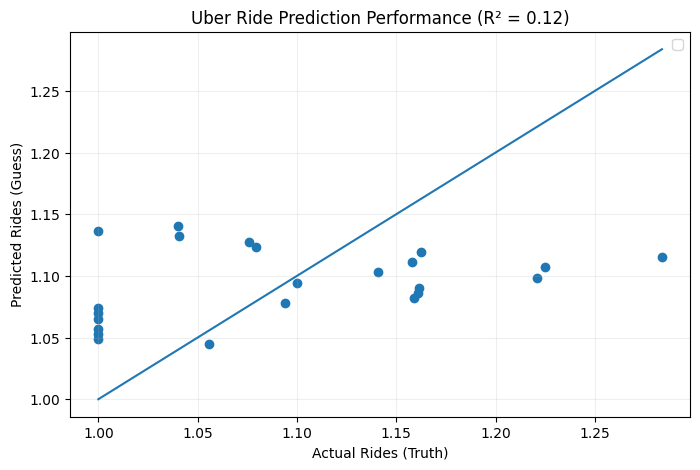

In [ ]:
# 2. Model & Baseline
model = LinearRegression().fit(X, y)
pred = model.predict(X)

# 3. Informative Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y, pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '-')

plt.xlabel("Actual Rides (Truth)")
plt.ylabel("Predicted Rides (Guess)")
plt.title(f"Uber Ride Prediction Performance (R² = {r2_score(y, pred):.2f})")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Measure error
mae = mean_absolute_error(y, pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 0.07
